# EDAノートブック

本ノートブックは、分析業務で使うEDAを固定手順で実行するための定型版です。
可視化結果は相対パスで `reports/figures` に保存します。


## 固定EDA計画
1. データ読み込みと基本確認
2. 列型・記述統計の確認
3. 欠損率の集計と可視化
4. 数値列の分布確認
5. カテゴリ列の主要分布確認
6. 目的変数の分布と偏り確認
7. 数値特徴量の相関確認
8. 日付列の時系列傾向確認（存在時）
9. 観察結果サマリ


In [1]:
from pathlib import Path
import warnings

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")
warnings.filterwarnings("ignore", message="Glyph .* missing from font")
plt.rcParams["axes.unicode_minus"] = False

JP_FONT_CANDIDATES = [
    "Yu Gothic",
    "Meiryo",
    "MS Gothic",
    "Noto Sans CJK JP",
    "IPAexGothic",
    "IPAGothic",
    "TakaoGothic",
]


def configure_japanese_font() -> str:
    available = {f.name for f in fm.fontManager.ttflist}
    for name in JP_FONT_CANDIDATES:
        if name in available:
            plt.rcParams["font.family"] = name
            return name
    plt.rcParams["font.sans-serif"] = JP_FONT_CANDIDATES + list(plt.rcParams.get("font.sans-serif", []))
    return ""


selected_font = configure_japanese_font()
if selected_font:
    print(f"日本語フォント: {selected_font}")
else:
    print("日本語フォント候補が見つからないため、既定フォントで描画します。")

ENCODINGS = ("utf-8-sig", "utf-8", "cp932", "shift_jis", "euc_jp")

cwd = Path.cwd()
if (cwd / "configs" / "project_config.json").exists():
    analysis_root = cwd
elif (cwd.name == "notebooks") and (cwd.parent / "configs" / "project_config.json").exists():
    analysis_root = cwd.parent
elif (cwd / "artifacts" / "analysis_project" / "configs" / "project_config.json").exists():
    analysis_root = cwd / "artifacts" / "analysis_project"
else:
    analysis_root = cwd

FIG_DIR = analysis_root / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_csv_auto(path: Path):
    sep = "	" if path.suffix.lower() == ".tsv" else ","
    for enc in ENCODINGS:
        try:
            return pd.read_csv(path, encoding=enc, sep=sep), enc
        except UnicodeDecodeError:
            continue
    raise RuntimeError("CSVを既知エンコーディングで読み込めませんでした")


def is_pure_day_number_column(series: pd.Series) -> bool:
    numeric = pd.to_numeric(series, errors="coerce").dropna()
    if numeric.empty:
        return False
    if not np.all(np.isclose(numeric, np.round(numeric))):
        return False
    return bool(((numeric >= 1) & (numeric <= 31)).all())


日本語フォント: Yu Gothic


In [2]:
csv_rel = Path("data/train.csv")
candidates = [
    analysis_root / csv_rel,
    Path("data/train.csv"),
    Path("artifacts/analysis_project") / csv_rel,
]
csv_path = next((p for p in candidates if p.exists()), candidates[0])
df, used_encoding = load_csv_auto(csv_path)
target_col = "Outcome"
if target_col not in df.columns:
    target_col = df.columns[-1]
date_col_hint = "None".strip() or None

print(f"読み込みエンコーディング: {used_encoding}")
print(f"行数: {len(df):,} / 列数: {df.shape[1]:,}")
print(f"目的変数列: {target_col}")
display(df.head(10))


読み込みエンコーディング: utf-8-sig
行数: 3,000 / 列数: 10
目的変数列: Outcome


,index,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,8,110,76,0,0,39.547141,0.288328,26,0
1,2,8,91,74,32,0,39.508445,0.475601,50,0
2,6,1,84,68,0,0,51.000158,0.237507,21,1
3,7,3,112,82,0,0,39.462710,0.491202,25,0
4,8,1,144,68,0,0,52.123800,0.276320,29,0
5,11,7,87,64,0,0,33.409500,0.429290,43,1
6,13,1,123,68,0,0,33.845807,0.239329,22,0
7,16,0,91,80,0,0,39.273486,0.191756,21,0
8,18,9,125,68,0,0,27.356397,0.655654,25,0
9,19,3,100,60,20,0,34.085432,0.441405,22,0


## 1. データ概要


データ概要
行数: 3000
列数: 10

列情報
index                         int64
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

先頭5行
   index  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  \
0      0            8      110             76              0        0   
1      2            8       91             74             32        0   
2      6            1       84             68              0        0   
3      7            3      112             82              0        0   
4      8            1      144             68              0        0   

         BMI  DiabetesPedigreeFunction  Age  Outcome  
0  39.547141                  0.288328   26        0  
1  39.508445                  0.475601   50 

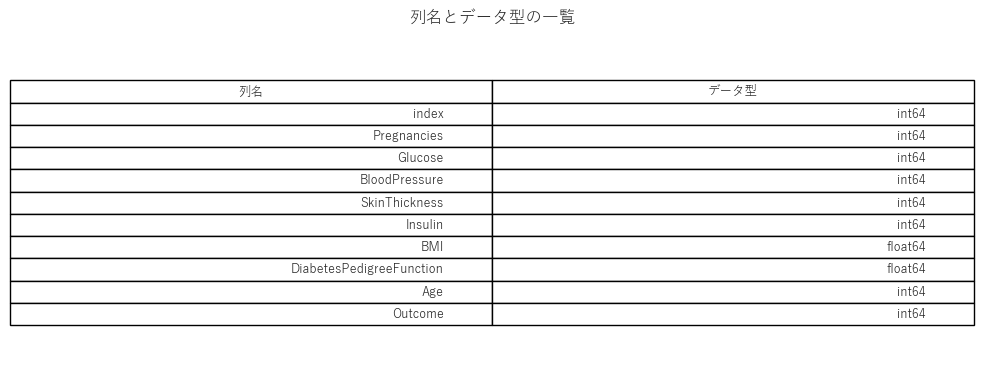

In [3]:
try:
    import matplotlib.pyplot as plt
    from pathlib import Path

    print('データ概要')
    print(f'行数: {df.shape[0]}')
    print(f'列数: {df.shape[1]}')
    print('\n列情報')
    print(df.dtypes)
    print('\n先頭5行')
    print(df.head())
    print('\n基本統計量')
    print(df.describe(include='all').T)

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(10, max(4, len(df.columns) * 0.35)))
    dtype_df = pd.DataFrame({'列名': df.columns, 'データ型': df.dtypes.astype(str).values})
    ax.axis('off')
    tbl = ax.table(cellText=dtype_df.values, colLabels=dtype_df.columns, loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.2)
    ax.set_title('列名とデータ型の一覧')
    plt.tight_layout()
    plt.savefig(Path(FIG_DIR) / 'overview_schema.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: overview_code: {_eda_exc}")
    dtype_summary = (
        df.dtypes.astype(str)
        .rename("dtype")
        .reset_index()
        .rename(columns={"index": "column"})
    )
    type_counts = dtype_summary["dtype"].value_counts().rename_axis("dtype").reset_index(name="count")
    print("列型サマリ")
    display(type_counts)
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    category_cols = [c for c in df.columns if c not in numeric_cols]
    print(f"数値列数: {len(numeric_cols)} / カテゴリ列数: {len(category_cols)}")
    display(dtype_summary.head(30))


## 2. 欠損分析


欠損値集計
Empty DataFrame
Columns: [欠損数, 欠損率(%)]
Index: []


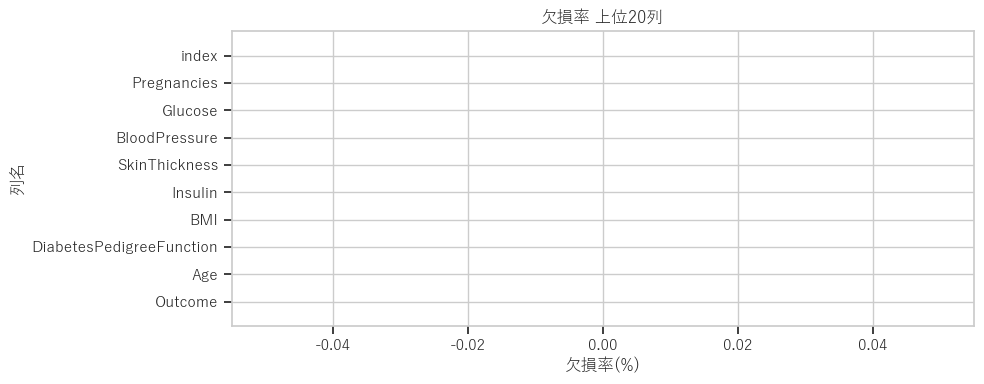

In [4]:
try:
    import matplotlib.pyplot as plt
    from pathlib import Path

    missing_count = df.isnull().sum().sort_values(ascending=False)
    missing_rate = (df.isnull().mean() * 100).sort_values(ascending=False)
    missing_df = pd.DataFrame({'欠損数': missing_count, '欠損率(%)': missing_rate})
    print('欠損値集計')
    print(missing_df[missing_df['欠損数'] > 0])

    plot_df = missing_df.head(20).iloc[::-1]
    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(10, max(4, len(plot_df) * 0.4)))
    plt.barh(plot_df.index.astype(str), plot_df['欠損率(%)'], color='tomato')
    plt.xlabel('欠損率(%)')
    plt.ylabel('列名')
    plt.title('欠損率 上位20列')
    for i, v in enumerate(plot_df['欠損率(%)']):
        if v > 0:
            plt.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(Path(FIG_DIR) / 'missing_rate_top20.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: missing_code: {_eda_exc}")
    missing_rate = (df.isna().mean() * 100).sort_values(ascending=False)
    display(missing_rate.rename("欠損率(%)").to_frame().head(20))
    top_missing = missing_rate.head(20)
    fig, ax = plt.subplots(figsize=(12, 5))
    top_missing.plot(kind="bar", ax=ax, color="#4c78a8")
    ax.set_title("欠損率 上位20列")
    ax.set_ylabel("欠損率(%)")
    ax.set_xlabel("列名")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "missing_rate_top20.png", dpi=160, bbox_inches="tight")
    plt.show()


## 3. 数値特徴量の分布


数値列の要約統計量
                           count         mean          std        min  \
index                     3000.0  2492.964667  1447.218078   0.000000   
Insulin                   3000.0    11.663333    45.064090   0.000000   
Glucose                   3000.0   113.733667    20.885612  57.000000   
BloodPressure             3000.0    68.743667    16.332755   0.000000   
SkinThickness             3000.0    11.164000    14.351159   0.000000   
Age                       3000.0    28.932000     8.469078  21.000000   
BMI                       3000.0    35.262073     7.568025   0.000775   
Pregnancies               3000.0     3.557000     3.032131   0.000000   
DiabetesPedigreeFunction  3000.0     0.400476     0.274666   0.145844   

                                  25%          50%          75%          max  
index                     1218.750000  2465.500000  3750.250000  4999.000000  
Insulin                      0.000000     0.000000     0.000000   579.000000  
Glucose               

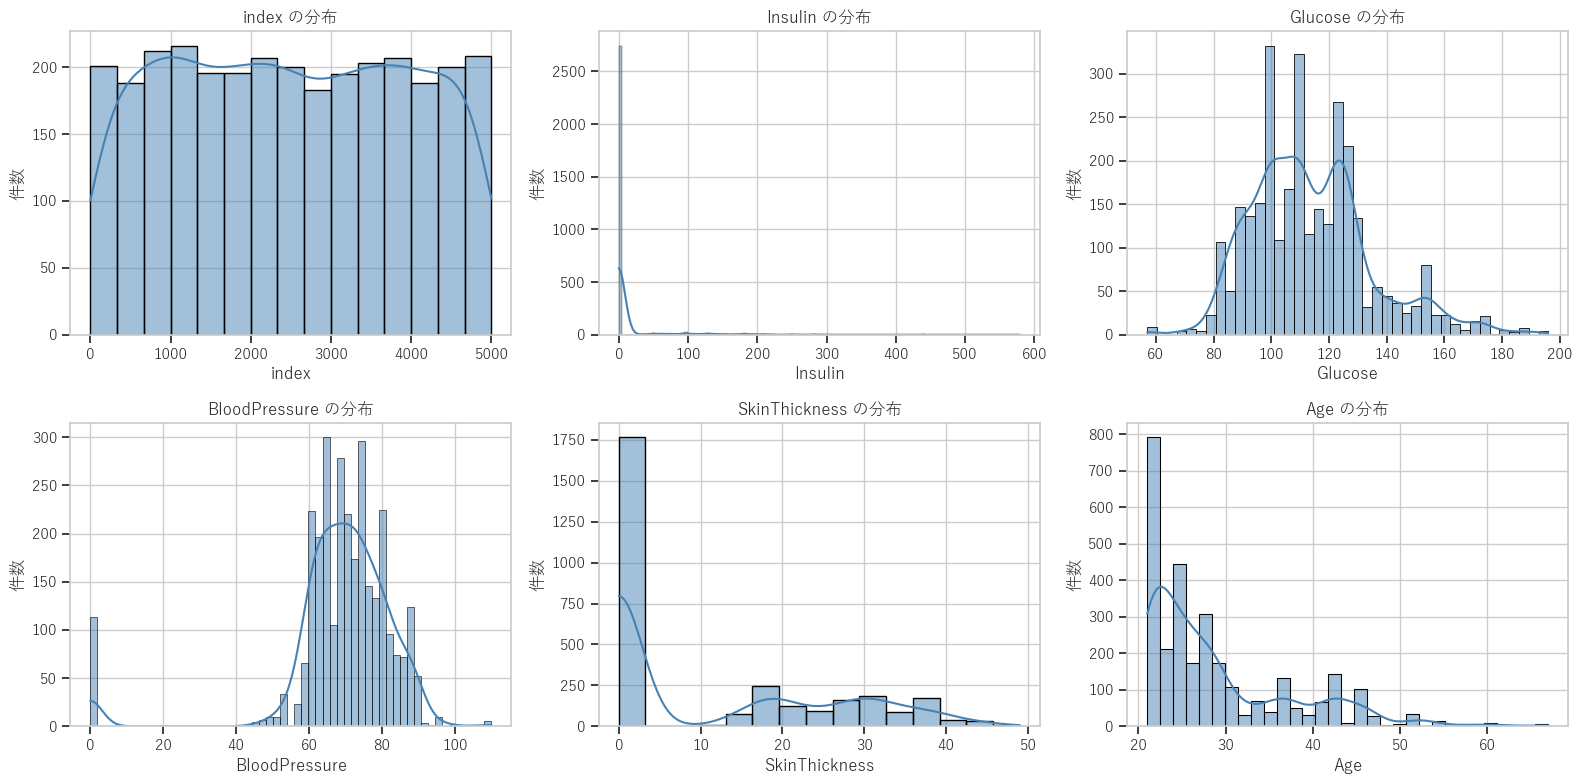


ゼロ値の多い数値列
               ゼロ件数    ゼロ比率(%)
Insulin        2744  91.466667
SkinThickness  1766  58.866667
Pregnancies     430  14.333333
BloodPressure   113   3.766667
index             1   0.033333


In [5]:
try:
    import matplotlib.pyplot as plt
    from pathlib import Path

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in num_cols:
        feature_num_cols = [c for c in num_cols if c != target_col]
    else:
        feature_num_cols = num_cols.copy()

    summary = df[feature_num_cols].describe().T.sort_values('std', ascending=False)
    print('数値列の要約統計量')
    print(summary)

    plot_cols = summary.head(6).index.tolist() if len(summary) > 0 else feature_num_cols[:6]
    if len(plot_cols) > 0:
        Path(FIG_DIR).mkdir(parents=True, exist_ok=True)
        n = len(plot_cols)
        ncols = 3
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
        axes = np.array(axes).reshape(-1)
        for ax, col in zip(axes, plot_cols):
            sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue')
            ax.set_title(f'{col} の分布')
            ax.set_xlabel(col)
            ax.set_ylabel('件数')
        for ax in axes[n:]:
            ax.axis('off')
        plt.tight_layout()
        plt.savefig(Path(FIG_DIR) / 'numeric_distribution_top6.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

    zero_like_cols = [c for c in feature_num_cols if (df[c] == 0).sum() > 0]
    if len(zero_like_cols) > 0:
        zero_stats = pd.DataFrame({
            'ゼロ件数': [(df[c] == 0).sum() for c in zero_like_cols],
            'ゼロ比率(%)': [(df[c] == 0).mean() * 100 for c in zero_like_cols]
        }, index=zero_like_cols).sort_values('ゼロ比率(%)', ascending=False)
        print('\nゼロ値の多い数値列')
        print(zero_stats)
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: numeric_code: {_eda_exc}")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if numeric_cols:
        display(df[numeric_cols].describe().T.head(20))
    target_col_local = "Outcome"
    if target_col_local not in df.columns:
        target_col_local = df.columns[-1]
    plot_cols = [c for c in numeric_cols if c != target_col_local][:6]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < len(plot_cols):
            col = plot_cols[i]
            sns.histplot(df[col], bins=30, ax=ax, color="#1f77b4")
            ax.set_title(f"{col} の分布")
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "numeric_distribution_top6.png", dpi=160, bbox_inches="tight")
    plt.show()


## 4. カテゴリ特徴量の分布


カテゴリ列候補


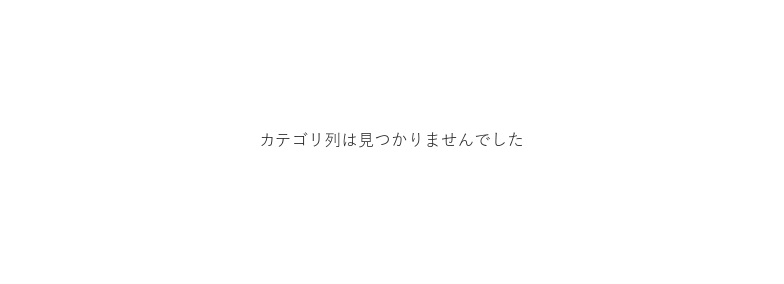

In [6]:
try:
    import matplotlib.pyplot as plt
    from pathlib import Path

    cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    small_num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if df[c].nunique(dropna=False) <= 10 and c != target_col]
    plot_cols = cat_cols + small_num_cols
    plot_cols = plot_cols[:3]

    print('カテゴリ列候補')
    for c in cat_cols + small_num_cols:
        print(f'\n[{c}]')
        print(df[c].value_counts(dropna=False).head(20))

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)
    if len(plot_cols) > 0:
        n = len(plot_cols)
        fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n))
        if n == 1:
            axes = [axes]
        for ax, col in zip(axes, plot_cols):
            vc = df[col].astype(str).value_counts(dropna=False).head(10)
            sns.barplot(x=vc.values, y=vc.index, ax=ax, color='seagreen')
            ax.set_title(f'{col} のカテゴリ分布（上位10件）')
            ax.set_xlabel('件数')
            ax.set_ylabel(col)
        plt.tight_layout()
        plt.savefig(Path(FIG_DIR) / 'categorical_distribution_top3.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
    else:
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.axis('off')
        ax.text(0.5, 0.5, 'カテゴリ列は見つかりませんでした', ha='center', va='center', fontsize=12)
        plt.tight_layout()
        plt.savefig(Path(FIG_DIR) / 'categorical_distribution_top3.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: categorical_code: {_eda_exc}")
    category_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
    plot_cols = category_cols[:3]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for i, ax in enumerate(axes):
        if i < len(plot_cols):
            col = plot_cols[i]
            vc = df[col].astype(str).fillna("欠損").value_counts().head(10)
            vc.plot(kind="bar", ax=ax, color="#59a14f")
            ax.set_title(f"{col} 上位カテゴリ")
            ax.tick_params(axis="x", rotation=45)
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "categorical_distribution_top3.png", dpi=160, bbox_inches="tight")
    plt.show()


## 5. 目的変数分析


目的変数の分布
Outcome
0    2283
1     717
Name: count, dtype: int64

目的変数の比率
Outcome
0    76.1
1    23.9
Name: proportion, dtype: float64


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_16004\273095996.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=target_col, order=order, palette='Set2')


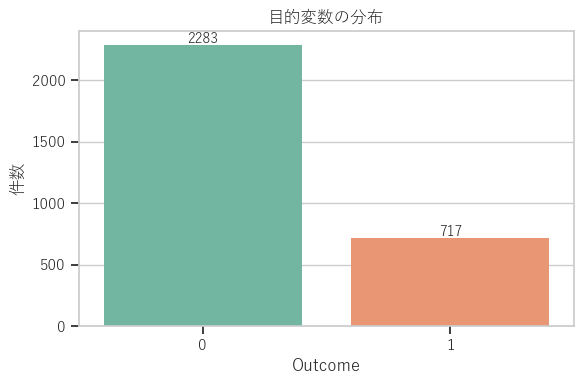


目的変数との相関
Age                         0.266000
BMI                         0.244350
Pregnancies                 0.197909
DiabetesPedigreeFunction    0.099075
Insulin                     0.079457
Glucose                     0.064677
BloodPressure               0.051347
index                       0.010270
SkinThickness               0.001112
Name: Outcome, dtype: float64


In [7]:
try:
    import matplotlib.pyplot as plt
    from pathlib import Path

    print('目的変数の分布')
    print(df[target_col].value_counts(dropna=False).sort_index())
    print('\n目的変数の比率')
    print(df[target_col].value_counts(normalize=True, dropna=False).sort_index() * 100)

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(6, 4))
    order = sorted(df[target_col].dropna().unique().tolist()) if df[target_col].notna().any() else None
    ax = sns.countplot(data=df, x=target_col, order=order, palette='Set2')
    plt.title('目的変数の分布')
    plt.xlabel(target_col)
    plt.ylabel('件数')
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f'{int(h)}', (p.get_x() + p.get_width() / 2, h), ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.savefig(Path(FIG_DIR) / 'target_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col]
    if len(num_cols) > 0:
        rel = df[num_cols + [target_col]].corr(numeric_only=True)[target_col].drop(target_col).sort_values(key=lambda s: s.abs(), ascending=False)
        print('\n目的変数との相関')
        print(rel)
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: target_code: {_eda_exc}")
    series = df[target_col]
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    if pd.api.types.is_numeric_dtype(series):
        uniq = series.dropna().nunique()
        if uniq > 20:
            sns.histplot(series.dropna(), bins=30, ax=ax[0], color="#f28e2b")
            ax[0].set_title("目的変数ヒストグラム")
            sns.boxplot(x=series.dropna(), ax=ax[1], color="#e15759")
            ax[1].set_title("目的変数ボックスプロット")
        else:
            vc = series.value_counts(dropna=False).sort_index()
            vc.plot(kind="bar", ax=ax[0], color="#f28e2b")
            ax[0].set_title("目的変数カテゴリ分布")
            (vc / vc.sum() * 100).round(2).plot(kind="bar", ax=ax[1], color="#e15759")
            ax[1].set_title("目的変数カテゴリ比率(%)")
    else:
        vc = series.astype(str).fillna("欠損").value_counts().head(20)
        vc.plot(kind="bar", ax=ax[0], color="#f28e2b")
        ax[0].set_title("目的変数カテゴリ分布")
        (vc / vc.sum() * 100).round(2).plot(kind="bar", ax=ax[1], color="#e15759")
        ax[1].set_title("目的変数カテゴリ比率(%)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "target_distribution.png", dpi=160, bbox_inches="tight")
    plt.show()


## 6. 相関分析


相関行列
                             index  Pregnancies   Glucose  BloodPressure  \
index                     1.000000     0.003418  0.036222       0.024221   
Pregnancies               0.003418     1.000000  0.067360      -0.008811   
Glucose                   0.036222     0.067360  1.000000       0.007822   
BloodPressure             0.024221    -0.008811  0.007822       1.000000   
SkinThickness            -0.005473     0.003640  0.022918       0.042476   
Insulin                   0.004264    -0.034456  0.010135       0.040159   
BMI                      -0.022387     0.011715  0.013754       0.242601   
DiabetesPedigreeFunction  0.027093    -0.027216  0.053021       0.098362   
Age                       0.015610     0.421213  0.035148       0.023235   
Outcome                   0.010270     0.197909  0.064677       0.051347   

                          SkinThickness   Insulin       BMI  \
index                         -0.005473  0.004264 -0.022387   
Pregnancies                    0

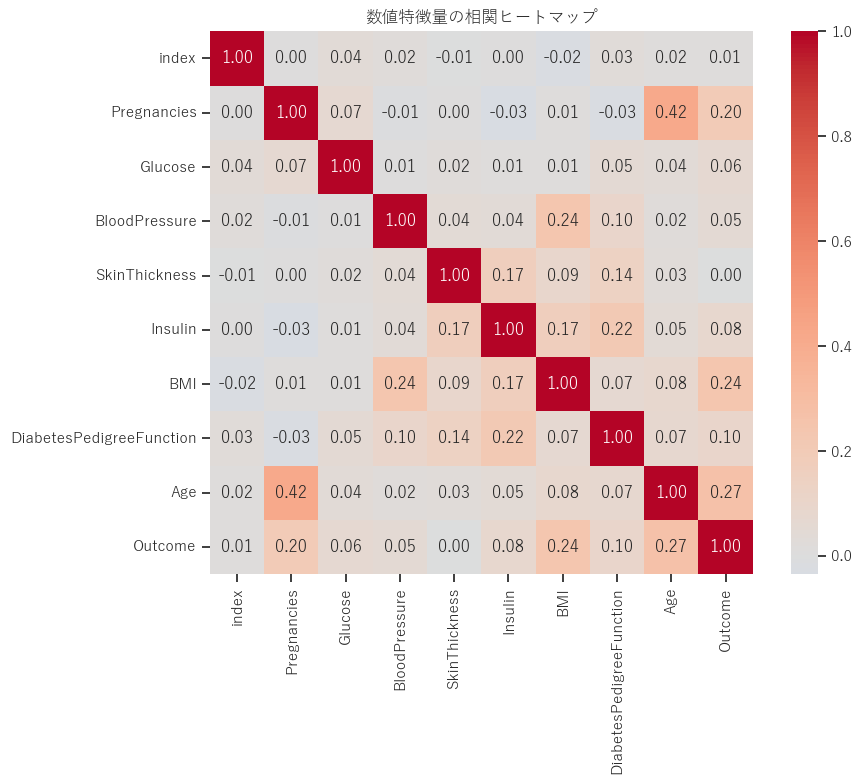


相関の強い組み合わせ
Pregnancies               Age                         0.421213
Age                       Outcome                     0.266000
BMI                       Outcome                     0.244350
BloodPressure             BMI                         0.242601
Insulin                   DiabetesPedigreeFunction    0.219013
Pregnancies               Outcome                     0.197909
Insulin                   BMI                         0.168287
SkinThickness             Insulin                     0.167506
                          DiabetesPedigreeFunction    0.141789
DiabetesPedigreeFunction  Outcome                     0.099075
BloodPressure             DiabetesPedigreeFunction    0.098362
SkinThickness             BMI                         0.092715
BMI                       Age                         0.082661
Insulin                   Outcome                     0.079457
DiabetesPedigreeFunction  Age                         0.072471
BMI                       DiabetesPedigreeF

In [8]:
try:
    import matplotlib.pyplot as plt
    from pathlib import Path

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) >= 2:
        corr = df[num_cols].corr(numeric_only=True)
        print('相関行列')
        print(corr)

        Path(FIG_DIR).mkdir(parents=True, exist_ok=True)
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
        plt.title('数値特徴量の相関ヒートマップ')
        plt.tight_layout()
        plt.savefig(Path(FIG_DIR) / 'feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        high_corr = upper.stack().sort_values(key=lambda s: s.abs(), ascending=False)
        print('\n相関の強い組み合わせ')
        print(high_corr.head(20))
    else:
        print('相関分析の対象となる数値列が不足しています')
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: corr_code: {_eda_exc}")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    fig, ax = plt.subplots(figsize=(10, 8))
    if len(numeric_cols) >= 2:
        corr = df[numeric_cols[:20]].corr(numeric_only=True)
        sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
        ax.set_title("数値特徴量の相関ヒートマップ（先頭20列）")
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "相関分析に十分な数値列がありません", ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "feature_correlation_heatmap.png", dpi=160, bbox_inches="tight")
    plt.show()


## 7. 日付分析


[warn] EDA section fallback: date_code: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")


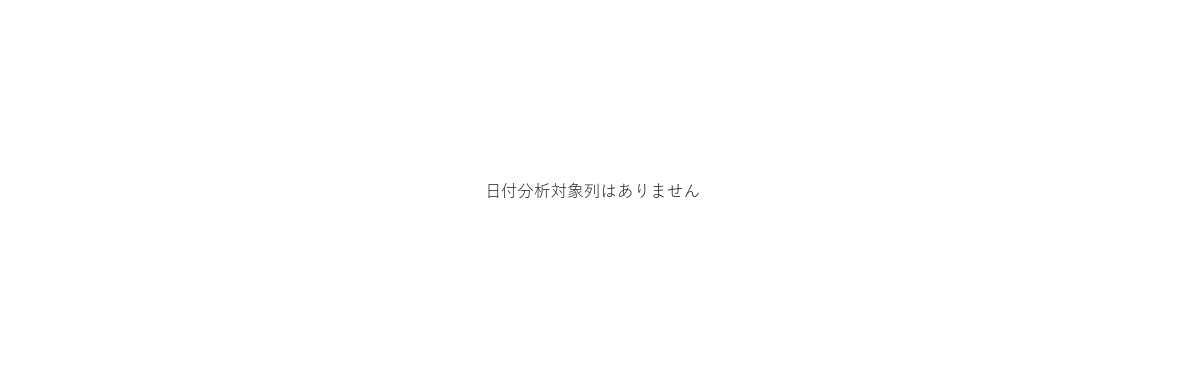

In [9]:
try:
    import matplotlib.pyplot as plt
    from pathlib import Path


    def is_pure_day_number_column(s):
        s2 = s.dropna()
        if s2.empty:
            return False
        num = pd.to_numeric(s2, errors='coerce')
        if num.isna().any():
            return False
        if not np.all(np.isclose(num, np.round(num))):
            return False
        vals = pd.Series(num.round().astype(int))
        return vals.between(1, 31).all()

    candidate_cols = []
    if date_col_hint not in [None, 'None', ''] and date_col_hint in df.columns:
        candidate_cols.append(date_col_hint)
    for c in df.columns:
        if c not in candidate_cols:
            candidate_cols.append(c)

    date_col = None
    for c in candidate_cols:
        if is_pure_day_number_column(df[c]):
            continue
        if df[c].dtype == 'datetime64[ns]':
            date_col = c
            break
        parsed = pd.to_datetime(df[c], errors='coerce')
        if parsed.notna().mean() >= 0.8 and parsed.nunique(dropna=True) > 1:
            date_col = c
            break

    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)
    if date_col is not None:
        tmp = df.copy()
        tmp[date_col] = pd.to_datetime(tmp[date_col], errors='coerce')
        tmp = tmp.dropna(subset=[date_col]).sort_values(date_col)
        trend = tmp.set_index(date_col).resample('M').size()
        print('日付列として採用:', date_col)
        print(trend.head())

        plt.figure(figsize=(12, 4))
        plt.plot(trend.index, trend.values, marker='o')
        plt.title(f'{date_col} の時系列件数推移（月次）')
        plt.xlabel('日付')
        plt.ylabel('件数')
        plt.tight_layout()
        plt.savefig(Path(FIG_DIR) / 'date_feature_trend.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
    else:
        print('分析対象の日付列は見つかりませんでした')
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.axis('off')
        ax.text(0.5, 0.5, '日付列は見つかりませんでした', ha='center', va='center', fontsize=12)
        plt.tight_layout()
        plt.savefig(Path(FIG_DIR) / 'date_feature_trend.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: date_code: {_eda_exc}")
    date_col = "None".strip() or date_col_hint
    fig, ax = plt.subplots(figsize=(12, 4))
    if date_col and date_col in df.columns and date_col != target_col:
        pure_day = is_pure_day_number_column(df[date_col])
        if pure_day:
            ax.axis("off")
            ax.text(0.5, 0.5, f"{date_col} は純粋な日番号列のため日付展開を行いません", ha="center", va="center", fontsize=12)
        else:
            parsed = pd.to_datetime(df[date_col], errors="coerce")
            valid = parsed.notna()
            if valid.sum() > 0:
                tmp = df.loc[valid, [target_col]].copy()
                tmp["_date"] = parsed.loc[valid]
                if pd.api.types.is_numeric_dtype(tmp[target_col]):
                    monthly = tmp.set_index("_date")[target_col].resample("M").mean()
                    monthly.plot(ax=ax, color="#4e79a7", marker="o")
                    ax.set_title("月次の目的変数平均")
                    ax.set_ylabel("平均値")
                else:
                    monthly = tmp.assign(_value=1).set_index("_date")["_value"].resample("M").sum()
                    monthly.plot(ax=ax, color="#4e79a7", marker="o")
                    ax.set_title("月次レコード件数")
                    ax.set_ylabel("件数")
                ax.set_xlabel("日付")
            else:
                ax.axis("off")
                ax.text(0.5, 0.5, f"{date_col} を日付として解釈できませんでした", ha="center", va="center", fontsize=12)
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "日付分析対象列はありません", ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "date_feature_trend.png", dpi=160, bbox_inches="tight")
    plt.show()


## 8. 観察結果サマリ


In [10]:
try:
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

    print('EDAサマリー')
    print(f'総行数: {len(df)}')
    print(f'総列数: {df.shape[1]}')
    print(f'数値列数: {len(num_cols)}')
    print(f'カテゴリ列数: {len(cat_cols)}')
    print(f'重複行数: {df.duplicated().sum()}')

    missing_rate = (df.isnull().mean() * 100).sort_values(ascending=False)
    print('\n欠損率 上位')
    print(missing_rate.head(10))

    if target_col in df.columns:
        print('\n目的変数の要約')
        print(df[target_col].value_counts(dropna=False).sort_index())
        if target_col in num_cols:
            target_corr = df[num_cols].corr(numeric_only=True)[target_col].drop(target_col).sort_values(key=lambda s: s.abs(), ascending=False)
            print('\n目的変数と相関の高い特徴量')
            print(target_corr.head(10))

    if len(num_cols) > 1:
        q1 = df[num_cols].quantile(0.25)
        q3 = df[num_cols].quantile(0.75)
        iqr = q3 - q1
        outlier_counts = (((df[num_cols] < (q1 - 1.5 * iqr)) | (df[num_cols] > (q3 + 1.5 * iqr))).sum()).sort_values(ascending=False)
        print('\n外れ値件数（IQR基準）')
        print(outlier_counts.head(10))
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: summary_code: {_eda_exc}")
    summary_rows = []
    summary_rows.append(f"レコード数: {len(df):,}")
    summary_rows.append(f"列数: {df.shape[1]:,}")
    summary_rows.append(f"欠損率上位列: {', '.join((df.isna().mean()*100).sort_values(ascending=False).head(3).index.tolist())}")
    summary_rows.append(f"数値列数: {len(df.select_dtypes(include=['number']).columns)}")
    summary_rows.append(f"カテゴリ列数: {len([c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])])}")
    summary_rows.append(f"目的変数候補: {target_col}")
    print("主要サマリ")
    for row in summary_rows:
        print(f"- {row}")


EDAサマリー
総行数: 3000
総列数: 10
数値列数: 10
カテゴリ列数: 0
重複行数: 0

欠損率 上位
index                       0.0
Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

目的変数の要約
Outcome
0    2283
1     717
Name: count, dtype: int64

目的変数と相関の高い特徴量
Age                         0.266000
BMI                         0.244350
Pregnancies                 0.197909
DiabetesPedigreeFunction    0.099075
Insulin                     0.079457
Glucose                     0.064677
BloodPressure               0.051347
index                       0.010270
SkinThickness               0.001112
Name: Outcome, dtype: float64

外れ値件数（IQR基準）
Outcome                     717
Insulin                     256
BMI                         221
BloodPressure               120
DiabetesPedigreeFunct